## Generate ECG Signals for Arrhythmia Classes using NeuroKit2

In [1]:
# Install neurokit2 if not already installed
!pip install neurokit2

In [2]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define parameters
sampling_rate = 250 # Hz
duration = 5     # seconds for each signal
heart_rates = [40, 90, 120] # bpm for the three classes
num_signals_per_class = 50 # Number of signals to generate for each class

ecg_database = []

for hr in heart_rates:
    print(f"Generating ECG signals for {hr} BPM...")
    for i in range(num_signals_per_class):
        # Simulate an ECG signal with the specified heart rate
        ecg_signal = nk.ecg_simulate(duration=duration, sampling_rate=sampling_rate, heart_rate=hr, noise=0.05)

        # Create a dictionary to store the signal and its metadata
        signal_data = {
            'heart_rate_bpm': hr,
            'class_label': f'{hr}bpm',
            'ecg_signal': ecg_signal
        }
        ecg_database.append(signal_data)

# Convert the list of dictionaries to a pandas DataFrame for easier handling
df_ecg = pd.DataFrame(ecg_database)

print(f"\nGenerated {len(df_ecg)} ECG signals.")
display(df_ecg.head())

Generating ECG signals for 40 BPM...
Generating ECG signals for 90 BPM...
Generating ECG signals for 120 BPM...

Generated 150 ECG signals.


,heart_rate_bpm,class_label,ecg_signal
0,40,40bpm,"[1.0289944071232522, 0.9974279394193728, 0.914..."
1,40,40bpm,"[1.0190864013331347, 0.9885589058224468, 0.908..."
2,40,40bpm,"[1.0564175004925964, 1.0244289975578906, 0.940..."
3,40,40bpm,"[1.0818551031324861, 1.0478550087810437, 0.958..."
4,40,40bpm,"[1.041553620781668, 1.0086130084053617, 0.9216..."


### Visualize a Sample ECG Signal

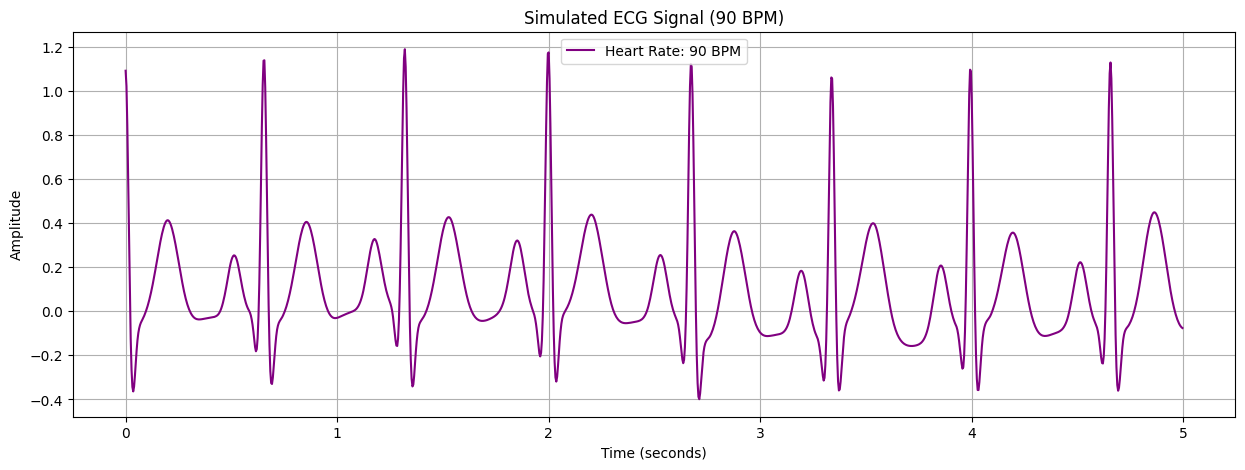

In [3]:
#@title { vertical-output: true}

# Select one signal to visualize (e.g., the first 90bpm signal)
sample_signal_data = df_ecg[df_ecg['class_label'] == '90bpm'].iloc[0]
sample_signal = sample_signal_data['ecg_signal']
sample_hr = sample_signal_data['heart_rate_bpm']

# Create a time vector
time = np.arange(len(sample_signal)) / sampling_rate

plt.figure(figsize=(15, 5))
plt.plot(time, sample_signal, color='purple', label=f'Heart Rate: {sample_hr} BPM')
plt.title(f'Simulated ECG Signal ({sample_hr} BPM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

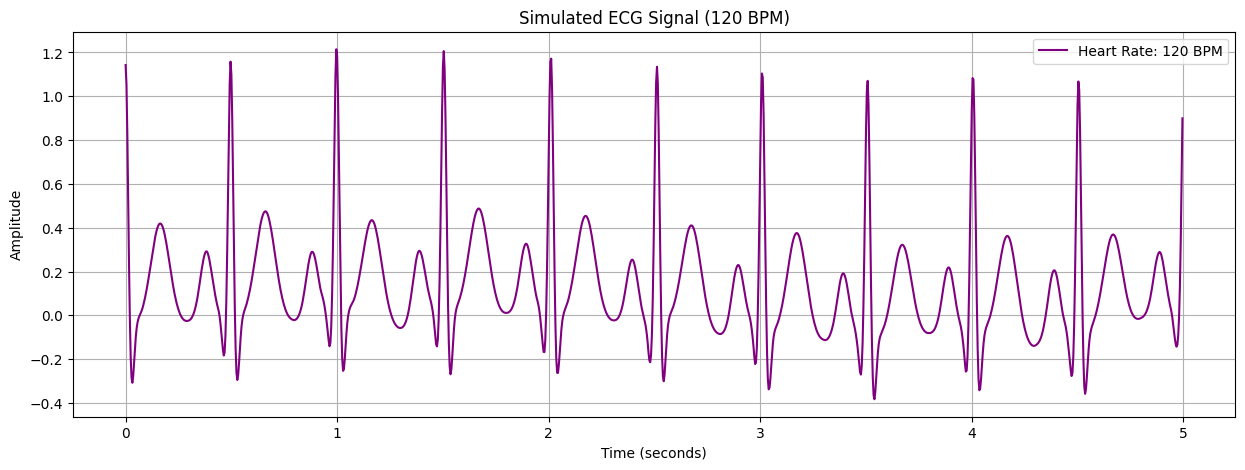

In [4]:
#@title { vertical-output: true}

# Select one signal to visualize (e.g., the first 90bpm signal)
sample_signal_data = df_ecg[df_ecg['class_label'] == '120bpm'].iloc[0]
sample_signal = sample_signal_data['ecg_signal']
sample_hr = sample_signal_data['heart_rate_bpm']

# Create a time vector
time = np.arange(len(sample_signal)) / sampling_rate

plt.figure(figsize=(15, 5))
plt.plot(time, sample_signal, color='purple', label=f'Heart Rate: {sample_hr} BPM')
plt.title(f'Simulated ECG Signal ({sample_hr} BPM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

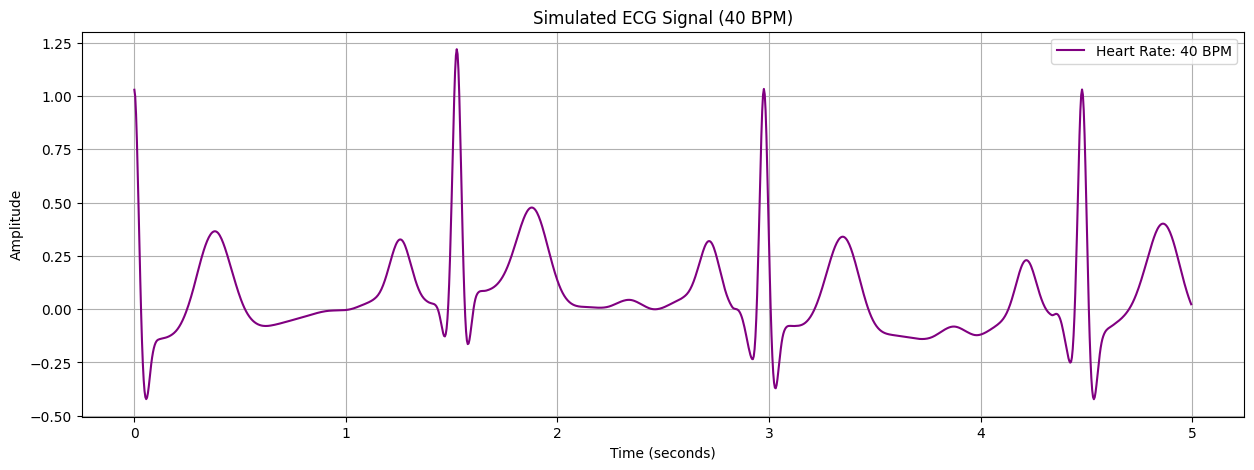

In [5]:
#@title { vertical-output: true}

# Select one signal to visualize (e.g., the first 90bpm signal)
sample_signal_data = df_ecg[df_ecg['class_label'] == '40bpm'].iloc[0]
sample_signal = sample_signal_data['ecg_signal']
sample_hr = sample_signal_data['heart_rate_bpm']

# Create a time vector
time = np.arange(len(sample_signal)) / sampling_rate

plt.figure(figsize=(15, 5))
plt.plot(time, sample_signal, color='purple', label=f'Heart Rate: {sample_hr} BPM')
plt.title(f'Simulated ECG Signal ({sample_hr} BPM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

In [6]:
df_ecg.head()

,heart_rate_bpm,class_label,ecg_signal
0,40,40bpm,"[1.0289944071232522, 0.9974279394193728, 0.914..."
1,40,40bpm,"[1.0190864013331347, 0.9885589058224468, 0.908..."
2,40,40bpm,"[1.0564175004925964, 1.0244289975578906, 0.940..."
3,40,40bpm,"[1.0818551031324861, 1.0478550087810437, 0.958..."
4,40,40bpm,"[1.041553620781668, 1.0086130084053617, 0.9216..."


In [7]:
df_ecg.groupby("class_label").size()

,0
class_label,
120bpm,50
40bpm,50
90bpm,50


<Axes: ylabel='class_label'>

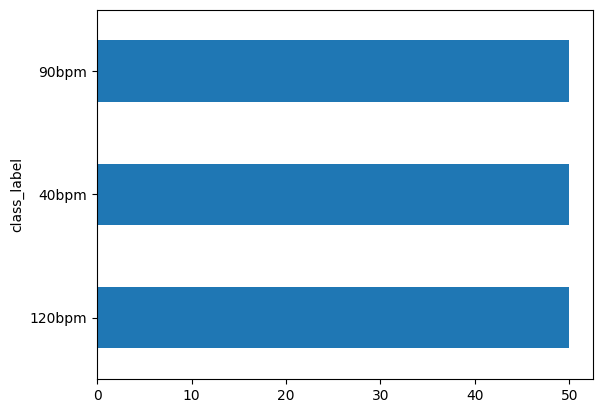

In [8]:
df_ecg.groupby("class_label").size().plot(kind="barh")

In [9]:
df_ecg.to_csv("ecg_database.csv", index=False)

# CHALLENGE

Apartir del dataset sintético de arritmias, extraer caracterśticas relevantes de las clases y crear un modelo clasificador tanto en tensorflow como en arduino usando raspberry pi pico.

Se recomienda usar 3 características relevantes o un PCA de 3 componentes. Deben exportar el firmware a wokwi y probar con 3 potenciometros.

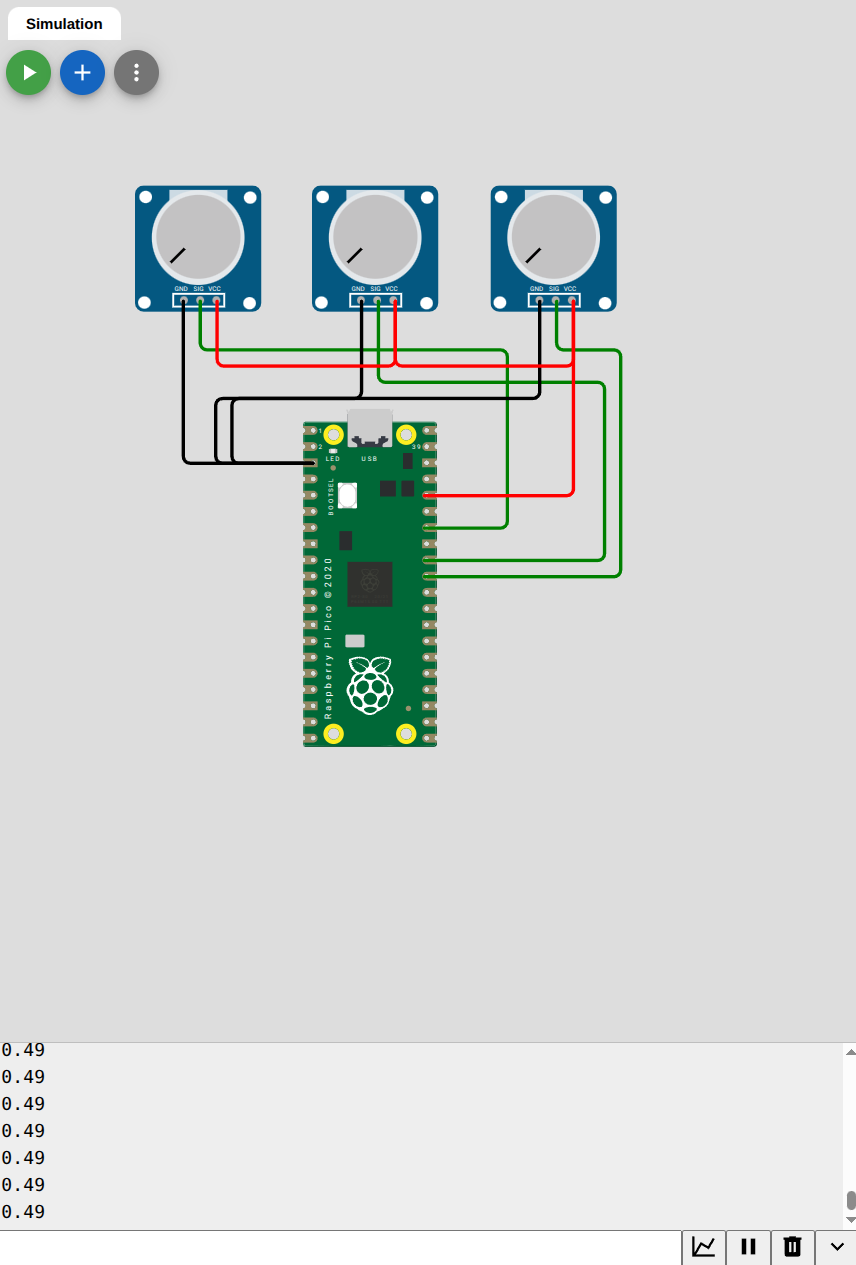

In [10]:
# CHALLENGE10
# Usaremos 3 características principales
# Intv RR, número de picos R y la frecuencia dominante de la señal
features = []

for _, row in df_ecg.iterrows():

    signal = row["ecg_signal"]
    label = row["class_label"]

    # Detectar picos R
    _, info = nk.ecg_peaks(
        signal,
        sampling_rate=sampling_rate
    )

    rpeaks = info["ECG_R_Peaks"]

    # Feature 1: cantidad de picos
    num_peaks = len(rpeaks)

    # Feature 2: intervalo RR promedio
    if len(rpeaks) > 1:
        rr = np.diff(rpeaks) / sampling_rate
        mean_rr = np.mean(rr)
    else:
        mean_rr = 0

    # Feature 3: frecuencia dominante
    freqs = np.fft.rfftfreq(
        len(signal),
        d=1 / sampling_rate
    )

    spectrum = np.abs(np.fft.rfft(signal))

    dominant_freq = freqs[np.argmax(spectrum[1:]) + 1]

    features.append({
        "mean_rr": mean_rr,
        "num_peaks": num_peaks,
        "dominant_freq": dominant_freq,
        "class_label": label
    })

df_features = pd.DataFrame(features)

display(df_features.head())

,mean_rr,num_peaks,dominant_freq,class_label
0,1.478,3,2.0,40bpm
1,1.474,3,2.0,40bpm
2,1.488,3,0.6,40bpm
3,1.502,3,0.6,40bpm
4,1.524,3,2.6,40bpm


In [11]:
# Conversión de cada clase a un número
label_map = {
    "40bpm": 0,
    "90bpm": 1,
    "120bpm": 2
}

df_features["target"] = (
    df_features["class_label"]
    .map(label_map)
)

# Definición de entrada y salida
X = df_features[
    ["mean_rr", "num_peaks", "dominant_freq"]
].values

y = df_features["target"].values

# Tamaños para confirmar
print(X.shape)
print(y.shape)

(150, 3)
(150,)


In [12]:
# División de subconjuntos de entrenamiento
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, #80% para el entrenamiento - 20% para prueba
    random_state=42,
    stratify=y
)

In [13]:
# Normalización
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Guardado de los parámetros de normalización
np.savez(
    "scaler_params.npz",
    mean=scaler.mean_,
    scale=scaler.scale_
)

In [16]:
# Modelo TensorFlow pequeño
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),

    tf.keras.layers.Dense(
        8,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        8,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        3,
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Entrenamiento
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3333 - loss: 1.0950 - val_accuracy: 0.3333 - val_loss: 1.0780
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3333 - loss: 1.0739 - val_accuracy: 0.3333 - val_loss: 1.0606
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3333 - loss: 1.0543 - val_accuracy: 0.3333 - val_loss: 1.0447
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3333 - loss: 1.0365 - val_accuracy: 0.3333 - val_loss: 1.0303
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3333 - loss: 1.0191 - val_accuracy: 0.3333 - val_loss: 1.0156
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6250 - loss: 1.0025 - val_accuracy: 0.5833 - val_loss: 1.0025
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6875 - loss: 0.9862 - val_accuracy: 0.5833 - val_loss: 0.9885
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6875 - loss: 0.9691 - val_accuracy: 0.5833 - val_loss: 0.9737


In [20]:
# Evaluación del modelo
from sklearn.metrics import confusion_matrix
import numpy as np

loss, accuracy = model.evaluate(
    X_test_scaled,
    y_test
)

print("Evaluación del entrenamiento:")
print("Accuracy:", accuracy)

# Matriz
y_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.1242
Evaluación del entrenamiento:
Accuracy: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [22]:
# Conversión para Pico
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("arrhythmia_model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpppm4uzal'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137016435093392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137016435094160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137016435093584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137016435094352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137016435094928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137016435092816: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [26]:

print("Valores para el Wokwi")
print("Mínimos:")
print(X_train.min(axis=0))

print("\nMáximos:")
print(X_train.max(axis=0))

print("\nMean:")
print(scaler.mean_)

print("\nScale:")
print(scaler.scale_)

Valores para el Wokwi
Mínimos:
[0.499 3.    0.6  ]

Máximos:
[1.524 9.    6.   ]

Mean:
[0.8880125  6.33333333 3.56333333]

Scale:
[0.43637098 2.49443826 1.84860007]


In [27]:
# Conversión para C++
!xxd -i arrhythmia_model.tflite > model_data.h

Resultados: Se intentó usar Wokwi con el modelo exportado como model_data.h y con las librería "Chirale_TensorFlowLite.h"

Sin embargo, no terminaba de cargar la página y siempre sale el error del tiempo de espera. La hipótesis de por qué sucede esto sería quizás el peso de la librería, debido a que el código compila de forma normal dentro del ArduinoIDE.
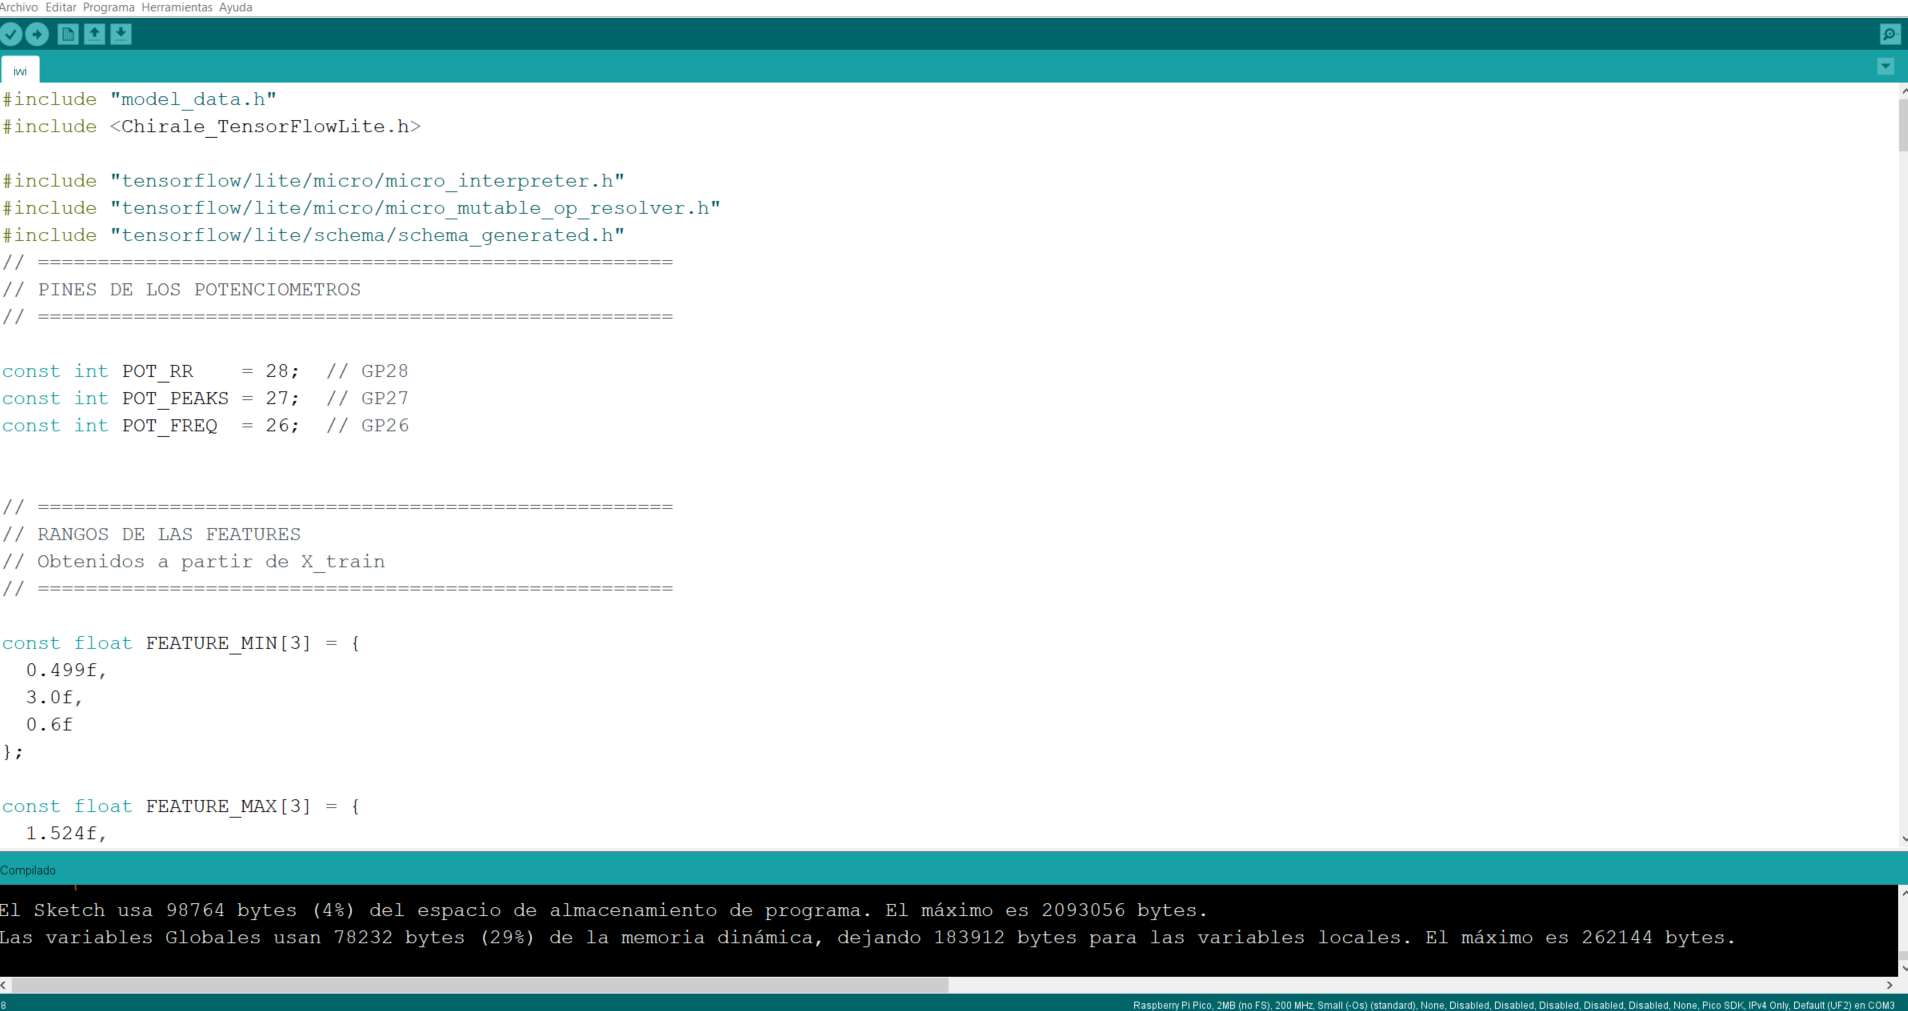

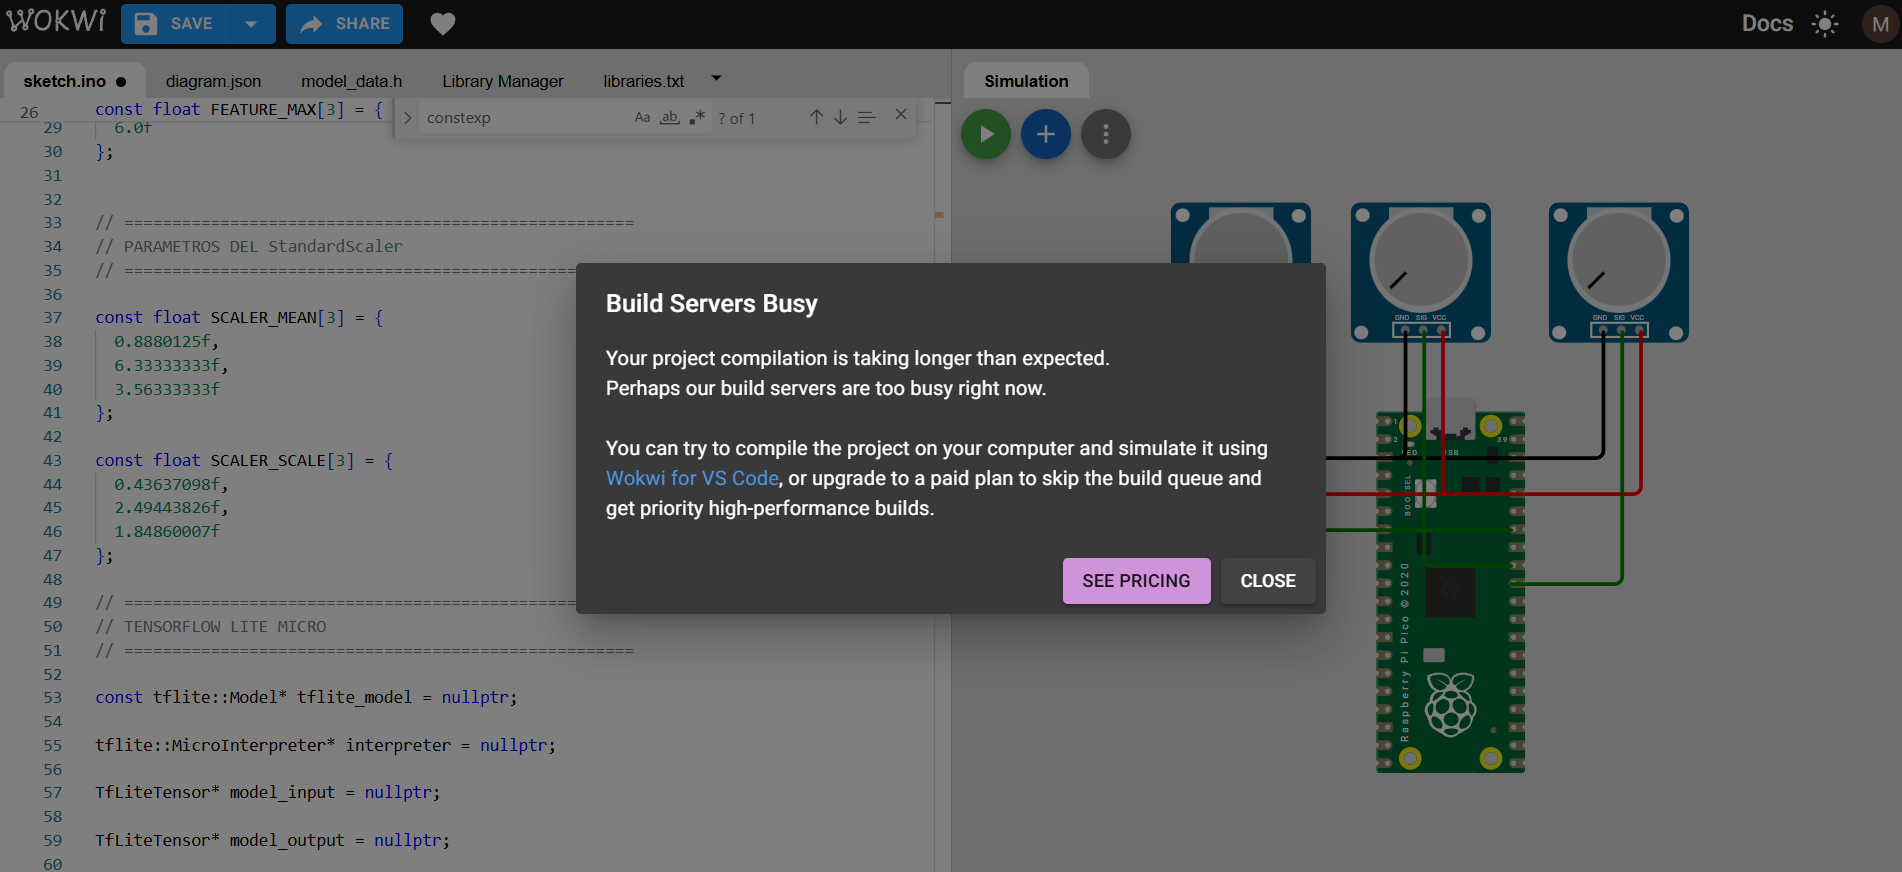